# TravelWatch AI — Model Training Notebook

INFO 5368-030: Practical Applications in Machine Learning (PAML)  
Cornell Tech — Group: Ruolan Chen, Lena Park, Seungyoon Kwon, Erica Tang, Alina Kapanova

This notebook implements from scratch using NumPy only:
- **Task 1 — Price Regression**: Ridge Regression vs. Lasso Regression on the EaseMyTrip dataset
- **Task 2 — Buy/Wait Classification**: Logistic Regression vs. KNN
- **Evaluation**: MSE, RMSE, MAE, R², F1, AUC-ROC
- **Serialization**: Save best model weights to JSON for Streamlit deployment

## 0. Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import kagglehub
import shutil

from sklearn.model_selection import train_test_split

%matplotlib inline
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

NumPy version: 2.4.4
Pandas version: 3.0.2


---
# Part 1 — Data Loading & Exploration

### 1.1 Load the EaseMyTrip dataset

Dataset: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction  
Download `Clean_Dataset.csv` and place it in a `datasets/` folder next to this notebook.

In [11]:
# Download
cache_path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
print(f"Downloaded to: {cache_path}")

# Create datasets directory
os.makedirs('../datasets', exist_ok=True)

# Copy file
src = os.path.join(cache_path, 'Clean_Dataset.csv')
dst = '../datasets/Clean_Dataset.csv'
shutil.copy2(src, dst)

print(f"✓ Dataset saved to: {dst}")

Downloaded to: /home/flyingc/.cache/kagglehub/datasets/shubhambathwal/flight-price-prediction/versions/2
✓ Dataset saved to: ../datasets/Clean_Dataset.csv


In [12]:
df = pd.read_csv('../datasets/Clean_Dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [13]:
# Inspect columns and data types
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

Missing values:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [14]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


### 1.2 Data Exploration Plots

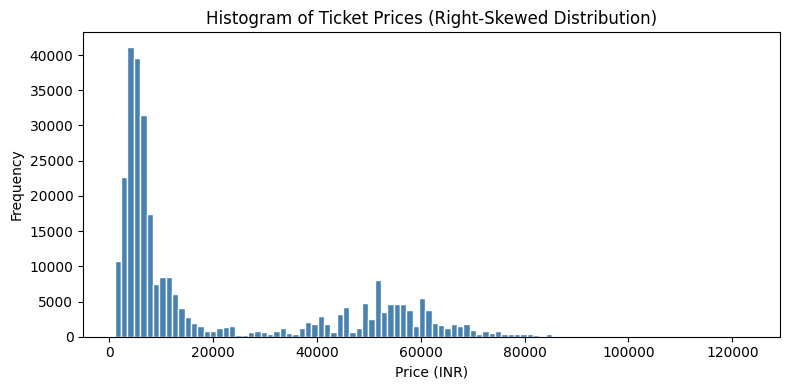

In [15]:
# Histogram of ticket prices (right-skewed, motivates log transform)
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=100, color='steelblue', edgecolor='white')
plt.title('Histogram of Ticket Prices (Right-Skewed Distribution)')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

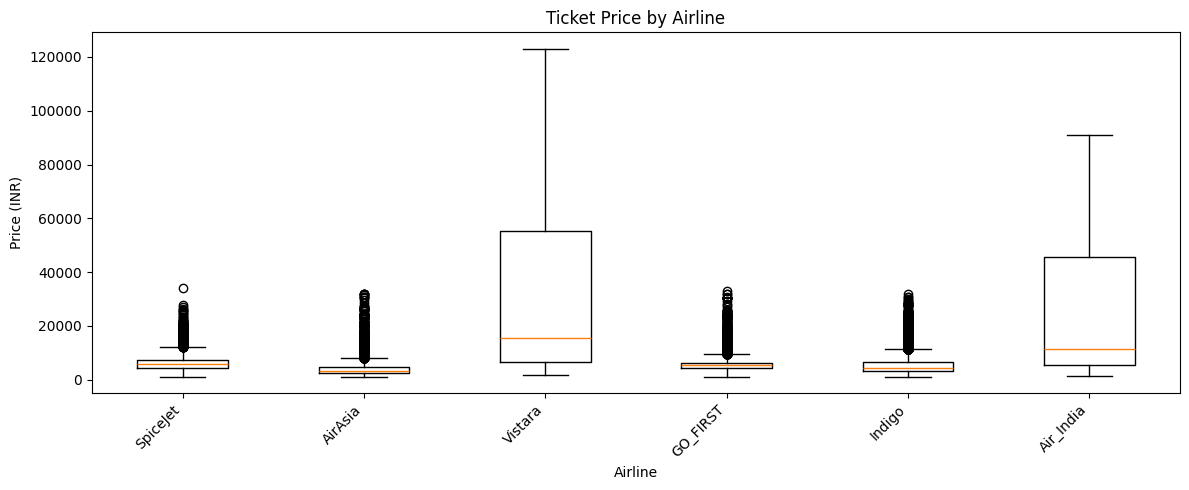

In [17]:
# Box plot: price by airline
airlines = df['airline'].unique()
data_by_airline = [df[df['airline'] == a]['price'].values for a in airlines]

plt.figure(figsize=(12, 5))
plt.boxplot(data_by_airline, tick_labels=airlines, vert=True)
plt.xticks(rotation=45, ha='right')
plt.title('Ticket Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

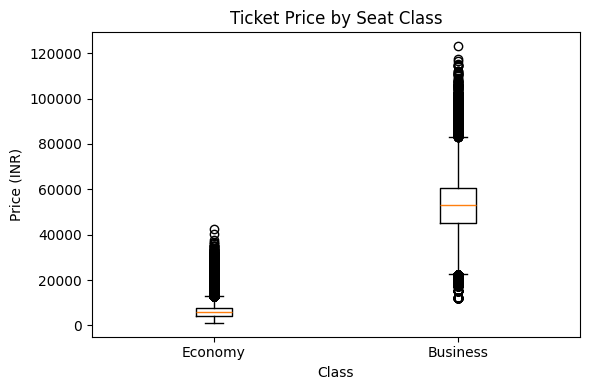

In [19]:
# Box plot: price by class
classes = df['class'].unique()
data_by_class = [df[df['class'] == c]['price'].values for c in classes]

plt.figure(figsize=(6, 4))
plt.boxplot(data_by_class, tick_labels=classes)
plt.title('Ticket Price by Seat Class')
plt.xlabel('Class')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot: days_left vs price (non-linear trend)
sample = df.sample(n=5000, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(sample['days_left'], sample['price'], alpha=0.2, s=5, color='steelblue')
plt.title('Price vs Days Left Until Departure')
plt.xlabel('Days Left')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

In [ ]:
# Pearson correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr().values

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

---
# Part 2 — Data Preprocessing

### 2.1 Drop duplicates and missing values

In [ ]:
df = df.drop_duplicates()
df = df.dropna()
# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print(f'Shape after cleaning: {df.shape}')

### 2.2 Outlier removal via IQR

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = len(df)
df = df[(df['price'] >= lower) & (df['price'] <= upper)]
print(f'Removed {before - len(df)} outliers. Shape: {df.shape}')

### 2.3 Feature encoding (one-hot encode categoricals)

In [ ]:
# Encode duration: convert 'Xh Ym' string to total minutes if needed
# The Clean_Dataset.csv has duration as float hours — check and handle
print('Duration sample:', df['duration'].head())
print('Duration dtype:', df['duration'].dtype)

In [ ]:
# One-hot encode: airline, source_city, destination_city, departure_time, arrival_time, class, stops
categorical_cols = ['airline', 'source_city', 'destination_city',
                    'departure_time', 'arrival_time', 'class', 'stops']

df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f'Shape after one-hot encoding: {df_encoded.shape}')
df_encoded.head()

### 2.4 Build feature matrix X and target y

In [ ]:
# Drop non-feature columns (flight id if present)
drop_cols = ['flight', 'price']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]

feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = np.asarray(df_encoded[feature_cols].values, dtype=float)
y = np.asarray(df_encoded['price'].values, dtype=float)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features: {feature_cols}')

### 2.5 Train/Test Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

---
# Part 3 — Task 1: Price Regression

We implement Ridge and Lasso Regression **from scratch in NumPy** following the same pattern as the in-class Ridge Regression activity.

### 3.1 Helper functions

In [ ]:
def standardize(X):
    """
    Standardize features (zero mean, unit variance).
    Keeps bias column (first column) unchanged.
    Input
        - X: feature matrix with bias column prepended
    Output
        - X_normalized: standardized feature matrix
    """
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0) + 1e-7
    X_normalized = (X - means) / stds
    return np.hstack((X[:, :1], X_normalized[:, 1:]))

In [ ]:
def rr_predict(X, W):
    """
    Predict target values using regression weights W.
    Input
        - X: raw feature matrix (without bias)
        - W: weight vector (includes bias weight at index 0)
    Output
        - y_pred: predicted values
    """
    num_examples, _ = X.shape
    X_transform = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)
    return X_normalized.dot(W)

In [ ]:
def rr_update_weights(X, Y, W, lr, l2_penalty):
    """
    Update weights for Ridge Regression (L2 penalty) using gradient descent.
    Input
        - X: raw feature matrix
        - Y: target values
        - W: current weights
        - lr: learning rate
        - l2_penalty: L2 regularization strength (alpha)
    Output
        - W: updated weights
        - cost: RMSE cost at this step
    """
    num_examples, _ = X.shape
    X_transform = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)
    Y_pred = rr_predict(X, W)
    # Gradient: -2 * X^T(Y - Y_pred) + 2*alpha*W
    dW = (-2 * X_normalized.T.dot(Y - Y_pred) + 2 * l2_penalty * W) / num_examples
    W = W - lr * dW
    cost = np.sqrt(np.sum(np.power(Y - Y_pred, 2)) / len(Y_pred))
    return W, cost

In [ ]:
def lasso_update_weights(X, Y, W, lr, l1_penalty):
    """
    Update weights for Lasso Regression (L1 penalty) using subgradient descent.
    Input
        - X: raw feature matrix
        - Y: target values
        - W: current weights
        - lr: learning rate
        - l1_penalty: L1 regularization strength (alpha)
    Output
        - W: updated weights
        - cost: RMSE cost at this step
    """
    num_examples, num_features = X.shape
    X_transform = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalize = standardize(X_transform)
    W = W.reshape(-1, 1)
    Y_pred = rr_predict(X, W)
    Y = Y.reshape(-1, 1)
    # Subgradient of L1 penalty: sign(W)
    dW = np.zeros(num_features + 1).reshape(-1, 1)
    for j in range(len(W)):
        if W[j] > 0:
            dW[j] = (-2 * X_normalize[:, j].dot(Y - Y_pred) + l1_penalty) / num_examples
        else:
            dW[j] = (-2 * X_normalize[:, j].dot(Y - Y_pred) - l1_penalty) / num_examples
    W = W - lr * dW
    cost = np.sqrt(np.sum(np.power(Y - Y_pred, 2)) / len(Y_pred))
    return W.flatten(), cost

In [ ]:
def fit(X, Y, lr, num_iterations, l_norm_penalty, penalty_mode=2):
    """
    Fit Ridge or Lasso regression using gradient descent.
    Input
        - X: feature matrix
        - Y: target values
        - lr: learning rate
        - num_iterations: number of gradient descent steps
        - l_norm_penalty: regularization strength (alpha)
        - penalty_mode: 2 = Ridge (L2), 1 = Lasso (L1)
    Output
        - W: trained weight vector
        - cost_history: list of RMSE values per iteration
    """
    num_examples, num_features = X.shape
    W = np.zeros(num_features + 1)  # +1 for bias
    cost_history = []
    for _ in range(num_iterations):
        if penalty_mode == 2:
            W, cost = rr_update_weights(X, Y, W, lr, l_norm_penalty)
        else:
            W, cost = lasso_update_weights(X, Y, W, lr, l_norm_penalty)
        cost_history.append(cost)
    return W, cost_history

### 3.2 Evaluation metrics

In [ ]:
def rmse_func(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(np.sum(np.power(y_true - y_pred, 2)) / len(y_true))

def mae_func(y_true, y_pred):
    """Mean Absolute Error"""
    return np.sum(np.abs(y_true - y_pred)) / len(y_true)

def mse_func(y_true, y_pred):
    """Mean Squared Error"""
    return np.sum(np.power(y_true - y_pred, 2)) / len(y_true)

def r2_score(y_true, y_pred):
    """Coefficient of Determination (R²) = 1 - RSS/TSS"""
    tss = np.sum(np.power(y_true - np.mean(y_true), 2))
    rss = np.sum(np.power(y_true - y_pred, 2))
    return 1 - (rss / tss)

def print_regression_metrics(mode, y_true, y_pred, print_results=True):
    rmse = rmse_func(y_true, y_pred)
    mae  = mae_func(y_true, y_pred)
    mse  = mse_func(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if print_results:
        print(f'{mode} — RMSE: {rmse:.2f} | MAE: {mae:.2f} | MSE: {mse:.2f} | R²: {r2:.4f}')
    return rmse, mae, mse, r2

### 3.3 Train Ridge Regression

In [ ]:
# Ridge Regression hyperparameters
ridge_lr         = 0.01
ridge_iterations = 200
ridge_alpha      = 1.0
penalty_mode     = 2  # 2 = Ridge

print('Training Ridge Regression...')
ridge_W, ridge_cost_history = fit(X_train, y_train, ridge_lr, ridge_iterations, ridge_alpha, penalty_mode=2)
print('Done.')

In [ ]:
# Evaluate Ridge
ridge_y_pred = rr_predict(X_test, ridge_W)
print('=== Ridge Regression ===')
print_regression_metrics('Test', y_test, ridge_y_pred)

In [ ]:
# Plot Ridge cost history
plt.figure(figsize=(7, 4))
plt.scatter(np.arange(len(ridge_cost_history)), ridge_cost_history, s=5, color='steelblue')
plt.title('Ridge Regression — Cost vs Training Iteration')
plt.xlabel('Training Iteration')
plt.ylabel('RMSE Cost')
plt.tight_layout()
plt.show()

### 3.4 Train Lasso Regression

In [ ]:
# Lasso Regression hyperparameters
lasso_lr         = 0.01
lasso_iterations = 200
lasso_alpha      = 1.0

print('Training Lasso Regression...')
lasso_W, lasso_cost_history = fit(X_train, y_train, lasso_lr, lasso_iterations, lasso_alpha, penalty_mode=1)
print('Done.')

In [ ]:
# Evaluate Lasso
lasso_y_pred = rr_predict(X_test, lasso_W)
print('=== Lasso Regression ===')
print_regression_metrics('Test', y_test, lasso_y_pred)

### 3.5 Ridge vs. Lasso — Learning Curves

In [ ]:
def plot_learning_curves_regression(X_train, X_val, y_train, y_val,
                                     lr=0.01, num_iterations=100, penalty=1.0, penalty_mode=2,
                                     step=500):
    """
    Plot learning curves for regression by incrementally increasing training set size.
    Returns dict of train/val R² error lists.
    """
    train_r2, val_r2, sizes = [], [], []
    for m in range(100, len(X_train) + 1, step):
        W, _ = fit(X_train[:m], y_train[:m], lr, num_iterations, penalty, penalty_mode=penalty_mode)
        y_tr_pred  = rr_predict(X_train[:m], W)
        y_val_pred = rr_predict(X_val, W)
        train_r2.append(r2_score(y_train[:m], y_tr_pred))
        val_r2.append(r2_score(y_val, y_val_pred))
        sizes.append(m)
    return sizes, train_r2, val_r2

In [ ]:
# NOTE: This cell can take a few minutes on the full dataset.
# Reduce step or subset data if needed.
print('Computing Ridge learning curve...')
ridge_sizes, ridge_train_r2, ridge_val_r2 = plot_learning_curves_regression(
    X_train, X_test, y_train, y_test, lr=0.01, num_iterations=50, penalty=1.0, penalty_mode=2, step=2000)

print('Computing Lasso learning curve...')
lasso_sizes, lasso_train_r2, lasso_val_r2 = plot_learning_curves_regression(
    X_train, X_test, y_train, y_test, lr=0.01, num_iterations=50, penalty=1.0, penalty_mode=1, step=2000)

print('Done.')

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(ridge_sizes, ridge_train_r2, 'b-+', linewidth=2, label='Ridge — Train')
plt.plot(ridge_sizes, ridge_val_r2,   'b-',  linewidth=2, label='Ridge — Val')
plt.plot(lasso_sizes, lasso_train_r2, 'r-+', linewidth=2, label='Lasso — Train')
plt.plot(lasso_sizes, lasso_val_r2,   'r-',  linewidth=2, label='Lasso — Val')
plt.legend(loc='lower right', fontsize=12)
plt.xlabel('Training Set Size', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Learning Curves — Ridge vs Lasso')
plt.tight_layout()
plt.show()

### 3.6 Hyperparameter tuning — Effect of alpha (L2/L1 penalty)

In [ ]:
alphas = [0.01, 0.1, 1.0, 5.0, 10.0]
ridge_alpha_r2, lasso_alpha_r2 = [], []

for alpha in alphas:
    W_r, _ = fit(X_train, y_train, 0.01, 100, alpha, penalty_mode=2)
    W_l, _ = fit(X_train, y_train, 0.01, 100, alpha, penalty_mode=1)
    ridge_alpha_r2.append(r2_score(y_test, rr_predict(X_test, W_r)))
    lasso_alpha_r2.append(r2_score(y_test, rr_predict(X_test, W_l)))

plt.figure(figsize=(7, 4))
plt.plot(alphas, ridge_alpha_r2, 'b-o', label='Ridge')
plt.plot(alphas, lasso_alpha_r2, 'r-o', label='Lasso')
plt.legend(fontsize=12)
plt.xlabel('Alpha (regularization strength)', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Effect of Alpha on R²')
plt.tight_layout()
plt.show()

print('Ridge R² per alpha:', [f'{v:.4f}' for v in ridge_alpha_r2])
print('Lasso R² per alpha:', [f'{v:.4f}' for v in lasso_alpha_r2])

### 3.7 Select best regression model

In [ ]:
ridge_r2 = r2_score(y_test, rr_predict(X_test, ridge_W))
lasso_r2 = r2_score(y_test, rr_predict(X_test, lasso_W))

print(f'Ridge R²: {ridge_r2:.4f}')
print(f'Lasso R²: {lasso_r2:.4f}')

# Deploy Ridge if Lasso is within 2 percentage points
if lasso_r2 >= ridge_r2 - 0.02:
    best_reg_model = 'Ridge'
    best_reg_W = ridge_W
else:
    best_reg_model = 'Lasso'
    best_reg_W = lasso_W

print(f'\nSelected regression model for deployment: {best_reg_model}')

---
# Part 4 — Generate Buy/Wait Labels

Since the EaseMyTrip dataset doesn't include a Buy/Wait label, we generate one programmatically:
- A flight is **BUY (1)** if its price is below the route's 30-day average price.
- Otherwise it is **WAIT (0)**.

In [ ]:
# Use price deviation from the mean price per route (source_city → destination_city)
df_encoded['route'] = df['source_city'].astype(str) + '_' + df['destination_city'].astype(str)
route_mean = df_encoded.groupby('route')['price'].transform('mean')
df_encoded['buy_wait'] = (df_encoded['price'] < route_mean).astype(int)

print('Buy/Wait label distribution:')
print(df_encoded['buy_wait'].value_counts())
print(f'Buy rate: {df_encoded["buy_wait"].mean():.2%}')

---
# Part 5 — Task 2: Buy/Wait Classification

Features for classification: predicted price deviation, days_left, duration, stops (encoded), class (encoded).

### 5.1 Build classification feature matrix

In [ ]:
# Use a focused feature set for classification
# Numeric features + class dummies + stops dummies
clf_base_cols = ['duration', 'days_left']
clf_dummy_cols = [c for c in df_encoded.columns if
                  c.startswith('class_') or c.startswith('stops_')]

clf_cols = clf_base_cols + clf_dummy_cols
clf_cols = [c for c in clf_cols if c in df_encoded.columns]

X_clf = np.asarray(df_encoded[clf_cols].values, dtype=float)
y_clf = np.asarray(df_encoded['buy_wait'].values, dtype=float)

print(f'Classification X shape: {X_clf.shape}')
print(f'Features used: {clf_cols}')

In [ ]:
# Normalize features for classification
def normalize_features(X):
    """
    Min-max normalize each feature column to [0, 1].
    Input
        - X: feature matrix (n_samples, n_features)
    Output
        - X_norm: normalized feature matrix
        - mins, maxs: normalization params for reuse at inference
    """
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    denom = (maxs - mins) + 1e-7
    X_norm = (X - mins) / denom
    return X_norm, mins, maxs

X_clf_norm, clf_mins, clf_maxs = normalize_features(X_clf)

# Train/test split
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf_norm, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print(f'Clf train: {X_clf_train.shape}, test: {X_clf_test.shape}')

### 5.2 Logistic Regression from scratch

In [ ]:
def sigmoid(z):
    """Sigmoid activation: 1 / (1 + exp(-z))"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lr_predict_proba(X, W, b):
    """
    Predict class probabilities P(y=1|x) using logistic regression.
    Input
        - X: feature matrix
        - W: weight vector
        - b: bias scalar
    Output
        - proba: probability of BUY (class 1)
    """
    return sigmoid(X.dot(W) + b)

def lr_predict(X, W, b, threshold=0.5):
    """
    Predict binary class labels (0 = WAIT, 1 = BUY).
    Input
        - X: feature matrix
        - W: weight vector
        - b: bias scalar
        - threshold: decision boundary
    Output
        - y_pred: predicted class labels
    """
    proba = lr_predict_proba(X, W, b)
    return (proba >= threshold).astype(int)

def compute_log_likelihood(X, Y, W, b):
    """
    Compute average log-likelihood (used to track gradient ascent).
    """
    scores = X.dot(W) + b
    logexp = np.log(1.0 + np.exp(-scores))
    mask = np.isinf(logexp)
    logexp[mask] = -scores[mask]
    return np.sum((Y - 1) * scores - logexp) / len(X)

def lr_update_weights(X, Y, W, b, learning_rate):
    """
    Update Logistic Regression weights using gradient ascent.
    Input
        - X: feature matrix
        - Y: binary labels (0 or 1)
        - W: current weights
        - b: current bias
        - learning_rate: step size
    Output
        - W: updated weights
        - b: updated bias
        - log_likelihood: current log-likelihood
    """
    num_examples = len(Y)
    y_pred = lr_predict_proba(X, W, b)
    dW = X.T.dot(Y - y_pred) / num_examples
    db = np.sum(Y - y_pred) / num_examples
    W = W + learning_rate * dW
    b = b + learning_rate * db
    ll = compute_log_likelihood(X, Y, W, b)
    return W, b, ll

def lr_fit(X, Y, num_iterations, learning_rate):
    """
    Train Logistic Regression from scratch using gradient ascent.
    Input
        - X: feature matrix
        - Y: binary labels
        - num_iterations: number of gradient ascent steps
        - learning_rate: step size
    Output
        - W: trained weights
        - b: trained bias
        - likelihood_history: list of log-likelihoods per iteration
    """
    num_features = X.shape[1]
    W = np.zeros(num_features)
    b = 0.0
    likelihood_history = []
    for _ in range(num_iterations):
        W, b, ll = lr_update_weights(X, Y, W, b, learning_rate)
        likelihood_history.append(ll)
    return W, b, likelihood_history

In [ ]:
# Train Logistic Regression
lr_iterations   = 300
lr_learning_rate = 0.1

print('Training Logistic Regression...')
lr_W, lr_b, lr_ll_history = lr_fit(X_clf_train, y_clf_train, lr_iterations, lr_learning_rate)
print('Done.')

# Plot log-likelihood convergence
plt.figure(figsize=(7, 4))
plt.scatter(np.arange(len(lr_ll_history)), lr_ll_history, s=5, color='steelblue')
plt.title('Logistic Regression — Log-Likelihood vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.tight_layout()
plt.show()

### 5.3 KNN from scratch

In [ ]:
def euclidean_distance(x1, x2):
    """Compute Euclidean distance between two vectors."""
    return np.sqrt(np.sum(np.power(x1 - x2, 2)))

def knn_predict(X_train, y_train, X_test, k):
    """
    K-Nearest Neighbors classification from scratch.
    Input
        - X_train: training feature matrix
        - y_train: training labels (0 or 1)
        - X_test: test feature matrix
        - k: number of neighbors
    Output
        - predictions: predicted class labels
        - probas: fraction of neighbors in class 1 (used as confidence)
    """
    predictions = []
    probas = []
    for test_point in X_test:
        # Compute distances to all training points
        distances = np.array([euclidean_distance(test_point, x_train)
                               for x_train in X_train])
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:k]
        k_labels  = y_train[k_indices]
        # Majority vote
        vote = int(np.sum(k_labels) > k / 2)
        confidence = np.sum(k_labels) / k
        predictions.append(vote)
        probas.append(confidence)
    return np.array(predictions), np.array(probas)

In [ ]:
# KNN is slow on large datasets — use a representative sample for speed
SAMPLE_SIZE = 5000  # increase if you have time / compute
idx = np.random.RandomState(42).choice(len(X_clf_train), size=min(SAMPLE_SIZE, len(X_clf_train)), replace=False)
X_knn_train = X_clf_train[idx]
y_knn_train = y_clf_train[idx]

print(f'KNN training on {len(X_knn_train)} samples, testing on {len(X_clf_test)} samples.')

In [ ]:
# Find best k via cross-validation on a small val split
k_values = [3, 5, 7, 11]
knn_val_accs = []

# Use a small validation slice for quick k-tuning
val_n = min(500, len(X_clf_test))
X_val_small = X_clf_test[:val_n]
y_val_small = y_clf_test[:val_n]

for k in k_values:
    preds, _ = knn_predict(X_knn_train, y_knn_train, X_val_small, k)
    acc = np.mean(preds == y_val_small)
    knn_val_accs.append(acc)
    print(f'k={k}: accuracy={acc:.4f}')

best_k = k_values[np.argmax(knn_val_accs)]
print(f'\nBest k: {best_k}')

In [ ]:
# Plot k vs accuracy
plt.figure(figsize=(6, 4))
plt.plot(k_values, knn_val_accs, 'b-o', linewidth=2)
plt.title('KNN — Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [ ]:
# Final KNN predictions with best k
# Use a subset of test set for speed if full test set is large
test_n = min(2000, len(X_clf_test))
print(f'Running KNN (k={best_k}) on {test_n} test samples...')
knn_preds, knn_probas = knn_predict(X_knn_train, y_knn_train, X_clf_test[:test_n], best_k)
knn_true = y_clf_test[:test_n]
print('Done.')

### 5.4 Classification evaluation metrics

In [ ]:
def compute_f1(y_true, y_pred):
    """
    Compute F1 score: 2*P*R / (P+R)
    Input
        - y_true: ground truth labels
        - y_pred: predicted labels
    Output
        - f1: F1 score
        - precision: precision
        - recall: recall
    """
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp + 1e-7)
    recall    = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)
    return f1, precision, recall

def compute_confusion_matrix(y_true, y_pred):
    """
    Compute 2x2 confusion matrix [[TN, FP], [FN, TP]].
    """
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    return np.array([[tn, fp], [fn, tp]])

def compute_auc_roc(y_true, y_scores):
    """
    Compute AUC-ROC using the trapezoidal rule.
    Input
        - y_true: ground truth binary labels
        - y_scores: predicted probabilities for class 1
    Output
        - auc: area under ROC curve
        - fpr_list, tpr_list: ROC curve points
    """
    thresholds = np.linspace(0, 1, 100)
    fpr_list, tpr_list = [], []
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        fn = np.sum((preds == 0) & (y_true == 1))
        tn = np.sum((preds == 0) & (y_true == 0))
        fpr = fp / (fp + tn + 1e-7)
        tpr = tp / (tp + fn + 1e-7)
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    fpr_arr = np.array(fpr_list)
    tpr_arr = np.array(tpr_list)
    auc = np.abs(np.trapz(tpr_arr, fpr_arr))
    return auc, fpr_arr, tpr_arr

def print_classification_metrics(model_name, y_true, y_pred, y_proba):
    f1, prec, rec = compute_f1(y_true, y_pred)
    acc = np.mean(y_pred == y_true)
    auc, _, _ = compute_auc_roc(y_true, y_proba)
    cm = compute_confusion_matrix(y_true, y_pred)
    print(f'=== {model_name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'F1 Score:  {f1:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')
    print(f'AUC-ROC:   {auc:.4f}')
    print(f'Confusion Matrix:\n{cm}')
    return f1, auc, cm

In [ ]:
# Evaluate Logistic Regression
lr_preds  = lr_predict(X_clf_test, lr_W, lr_b)
lr_probas = lr_predict_proba(X_clf_test, lr_W, lr_b)
lr_f1, lr_auc, lr_cm = print_classification_metrics('Logistic Regression', y_clf_test, lr_preds, lr_probas)

In [ ]:
# Evaluate KNN
knn_f1, knn_auc, knn_cm = print_classification_metrics('KNN', knn_true, knn_preds, knn_probas)

In [ ]:
# Plot ROC curves for both classifiers
_, lr_fpr, lr_tpr = compute_auc_roc(y_clf_test, lr_probas)
_, knn_fpr, knn_tpr = compute_auc_roc(knn_true, knn_probas)

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr,  lr_tpr,  'b-', linewidth=2, label=f'Logistic Regression (AUC={lr_auc:.3f})')
plt.plot(knn_fpr, knn_tpr, 'r-', linewidth=2, label=f'KNN (AUC={knn_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Logistic Regression vs KNN')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes, [lr_cm, knn_cm], ['Logistic Regression', 'KNN']):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Wait', 'Predicted Buy'])
    ax.set_yticklabels(['Actual Wait', 'Actual Buy'])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

### 5.5 Select best classification model

In [ ]:
print(f'Logistic Regression F1: {lr_f1:.4f}  |  KNN F1: {knn_f1:.4f}')

# Deploy Logistic Regression if KNN is within 3 percentage points in F1
if knn_f1 >= lr_f1 - 0.03:
    best_clf_model = 'Logistic Regression'
else:
    best_clf_model = 'KNN'

print(f'\nSelected classification model for deployment: {best_clf_model}')

---
# Part 6 — Summary Comparison Table

In [ ]:
ridge_metrics = print_regression_metrics('Ridge', y_test, rr_predict(X_test, ridge_W), print_results=False)
lasso_metrics = print_regression_metrics('Lasso', y_test, rr_predict(X_test, lasso_W), print_results=False)

results = pd.DataFrame({
    'Model':     ['Ridge Regression', 'Lasso Regression', 'Logistic Regression', 'KNN'],
    'Task':      ['Price Prediction', 'Price Prediction', 'Buy/Wait', 'Buy/Wait'],
    'RMSE':      [ridge_metrics[0], lasso_metrics[0], '-', '-'],
    'MAE':       [ridge_metrics[1], lasso_metrics[1], '-', '-'],
    'R²':        [f'{ridge_metrics[3]:.4f}', f'{lasso_metrics[3]:.4f}', '-', '-'],
    'F1':        ['-', '-', f'{lr_f1:.4f}', f'{knn_f1:.4f}'],
    'AUC-ROC':   ['-', '-', f'{lr_auc:.4f}', f'{knn_auc:.4f}'],
})
print(results.to_string(index=False))

---
# Part 7 — Save Model Weights to JSON

Serialize trained weights so the Streamlit app can load them at runtime without retraining.

In [ ]:
os.makedirs('../streamlit_app/model_weights', exist_ok=True)

model_artifacts = {
    'regression': {
        'best_model': best_reg_model,
        'ridge': {
            'W': ridge_W.tolist(),
            'r2': float(r2_score(y_test, rr_predict(X_test, ridge_W))),
            'rmse': float(rmse_func(y_test, rr_predict(X_test, ridge_W))),
            'mae': float(mae_func(y_test, rr_predict(X_test, ridge_W))),
        },
        'lasso': {
            'W': lasso_W.tolist(),
            'r2': float(r2_score(y_test, rr_predict(X_test, lasso_W))),
            'rmse': float(rmse_func(y_test, rr_predict(X_test, lasso_W))),
            'mae': float(mae_func(y_test, rr_predict(X_test, lasso_W))),
        },
        'feature_cols': feature_cols,
    },
    'classification': {
        'best_model': best_clf_model,
        'logistic_regression': {
            'W': lr_W.tolist(),
            'b': float(lr_b),
            'f1': float(lr_f1),
            'auc': float(lr_auc),
            'confusion_matrix': lr_cm.tolist(),
        },
        'knn': {
            'k': int(best_k),
            'X_train': X_knn_train.tolist(),
            'y_train': y_knn_train.tolist(),
            'f1': float(knn_f1),
            'auc': float(knn_auc),
            'confusion_matrix': knn_cm.tolist(),
        },
        'feature_cols': clf_cols,
        'clf_mins': clf_mins.tolist(),
        'clf_maxs': clf_maxs.tolist(),
    },
    'learning_curves': {
        'ridge_sizes': ridge_sizes,
        'ridge_train_r2': ridge_train_r2,
        'ridge_val_r2': ridge_val_r2,
        'lasso_sizes': lasso_sizes,
        'lasso_train_r2': lasso_train_r2,
        'lasso_val_r2': lasso_val_r2,
    }
}

output_path = '../streamlit_app/model_weights/travelwatch_models.json'
with open(output_path, 'w') as f:
    json.dump(model_artifacts, f, indent=2)

print(f'Model weights saved to {output_path}')

In [ ]:
# Verify saved file loads correctly
with open(output_path, 'r') as f:
    loaded = json.load(f)

print('Keys in saved artifact:', list(loaded.keys()))
print('Best regression model:', loaded['regression']['best_model'])
print('Best classification model:', loaded['classification']['best_model'])
print('Ridge R²:', loaded['regression']['ridge']['r2'])
print('LR F1:   ', loaded['classification']['logistic_regression']['f1'])